# CSC413 Homework 2 - Multilayer Perceptron

In this homework you will implement a linear multilayer perceptron, dive deeper into nonlinearities and modify your MLP implementation using the flower dataset from Homework 1. You are only allowed to use numpy -- no autodiff frameworks (torch, tensorflow, etc.).

You will complete the following implementations:

- Linear MLP
- Non-linear functions
  1. Sigmoid
  2. ReLU
  3. ELU
  3. Implement your own non-linear function
  4. SqueLU
- ReLU-MLP

**Notebook Version:** 1.0

- 1.0: Initial release

# Data Exploration

We will use a slightly modified version of the same flower dataset from homework 1. In this section we create the dataset and provide utility functions for visualization.

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Validation Data'}, xlabel='x₁', ylabel='x₂'>)

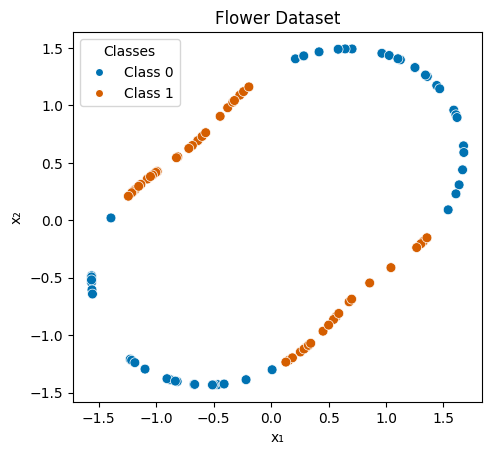

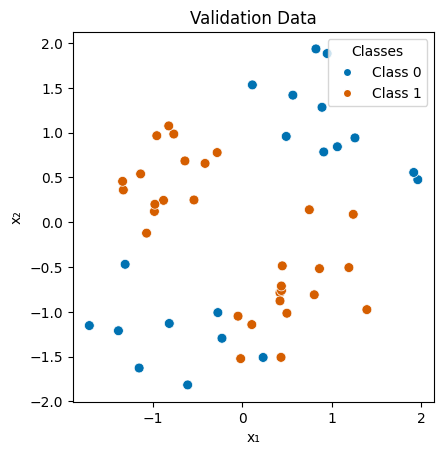

In [1155]:
# ============================================
# DO NOT MODIFY THIS CELL.
# ============================================

# Imports
from typing import List, Tuple
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Constants
SEED = 42
NUM_CLASSES = 2
N_FEATURES = 2
NUM_SAMPLES = 100
VALIDATION_SAMPLES = 50
NOISE_TRAIN = 0
NOISE_VALIDATION = 0.25

# Okabe–Ito color-blind friendly palette
OKABE_ITO_COLORS = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # green
    "#F0E442",  # yellow
    "#CC79A7",  # pink
    "#56B4E9",  # sky blue
    "#E69F00",  # orange
    "#000000",  # black
]

# Generates a synthetic flower-shaped dataset with specified number of classes and noise level.
def generate_flower_data(
    n_samples: int = 1000, noise: float = 0.1, num_classes: int = 3, seed: int = SEED
):
    rand = np.random.default_rng(seed)
    t = rand.uniform(0, 2 * np.pi, n_samples)

    # Petal shape: radius varies with class count
    r = 1 + 0.3 * np.sin(num_classes * t)

    # Convert polar coordinates to Cartesian and add noise
    x = r * np.cos(t) + noise * rand.standard_normal(n_samples)
    y = r * np.sin(t) + noise * rand.standard_normal(n_samples)

    X = np.stack([x, y], axis=1)

    # Assign class labels based on angular regions
    labels = ((t % (2 * np.pi)) / (2 * np.pi) * num_classes * 2).astype(
        int
    ) % num_classes
    y = labels.reshape(-1, 1)

    return shuffle(X, y, random_state=seed)

# Visualizes 2D classification data as a scatter plot with color-coded class labels.
def visualize_classification_data(features, labels, title: str = "Flower Dataset"):
    y_flat = np.asarray(labels).ravel().astype(int)
    unique_classes = np.unique(y_flat)
    cmap = ListedColormap(OKABE_ITO_COLORS[: max(1, unique_classes.size)])

    fig, ax = plt.subplots()
    ax.scatter(
        x=features[:, 0],
        y=features[:, 1],
        c=y_flat,
        cmap=cmap,
        edgecolors="white",
        linewidths=0.5,
        s=50,
    )

    handles = [
        plt.Line2D(
            [], [],
            marker="o", linestyle="",
            markerfacecolor=cmap(cls), markeredgecolor="white", markersize=6,
            label=f"Class {cls}"
        )
        for cls in unique_classes
    ]
    ax.legend(handles=handles, title="Classes", frameon=True)

    ax.set_title(title)
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_aspect("equal")
    ax.grid(False)
    return fig, ax


# ============================================
# Main Execution
# ============================================
np.random.seed(SEED)

# Generate datasets
flower_X, flower_y = generate_flower_data(
    num_classes=NUM_CLASSES, n_samples=NUM_SAMPLES, noise=NOISE_TRAIN
)
valid_X, valid_y = generate_flower_data(
    num_classes=NUM_CLASSES, n_samples=VALIDATION_SAMPLES, noise=NOISE_VALIDATION
)

# Standardize features
scaler = StandardScaler()
flower_X = scaler.fit_transform(flower_X)
valid_X = scaler.transform(valid_X)

# Visualize datasets
visualize_classification_data(flower_X, flower_y)
visualize_classification_data(valid_X, valid_y, title="Validation Data")

# Linear MLP

In this exercise, you will build and train a simple multi-layer perceptron (MLP) using only NumPy.

1. Start by implementing a linear layer. Complete the `Layer` class to perform the linear transformation
$$\mathbf{z} = \mathbf{W} \mathbf{X} + \mathbf{b}$$
which maps the input to the layer's output using the provided weight and bias initialization.

2. Assemble multiple linear layers into a complete MLP model. Complete the `LinearMLP` class by implementing the forward pass in its `__call__` function.

3. Implement forward and backward propagation.

  - Forward pass: Compute and store the activations (layer outputs) in the function `compute_forward_passes`.

  - Backward pass: Compute and store the partial derivatives (errors) that flow backward through the layers using `compute_partial_derivatives`. Then, calculate the gradients of the loss with respect to each layer's weights and biases in `compute_parameter_updates`. Store these gradients in the lists `weight_gradients` and `bias_gradients`, one entry per layer.

4. Update model parameters. Use the computed gradients to adjust weights and biases after each training step. Perform these updates in the `update_parameters` function using gradient descent.

## Tips

- Before coding, derive the key gradients by hand and sketch the computation graph to understand how information flows forward and backward through the network.  
- The gradient for the final softmax and cross-entropy layer is already provided in the helper function `step_linear_mlp`.

## Layer Class

The Layer class below represents a single fully connected (linear) layer in the MLP. Complete the code below to implement the forward pass that computes the output of this layer.

In [1156]:
class Layer:
    def __init__(self, input_dim, output_dim):
        '''
        Initialize a single linear layer.

        Parameters
        ----------
        input_dim : int
            Number of input features for this layer.
        output_dim : int
            Number of output units (neurons) for this layer.

        Attributes
        ----------
        weights : np.ndarray of shape (output_dim, input_dim)
            Weight matrix connecting inputs to outputs.
        biases : np.ndarray of shape (output_dim, 1)
            Bias vector added to each output unit.
        '''

        # ============================================
        # DO NOT MODIFY THIS FUNCTION.
        # ============================================

        # Stable initialization scheme (He initialization)
        self.weights = np.random.randn(
            output_dim, input_dim
        ) * np.sqrt(2.0 / input_dim)
        self.biases = np.zeros((output_dim, 1))

    def __call__(self, X):
        '''
        Compute the forward pass for this layer.

        Parameters
        ----------
        X : np.ndarray of shape (input_dim, batch_size)
            Input data matrix, where each column is one sample.

        Returns
        -------
        np.ndarray of shape (output_dim, batch_size)
            Output after applying the linear transformation:
            output = W X + b
        '''

        ##########################################

        # res = np.matmul(X.T, self.weights.T).T + self.biases
        # OR 

        res = np.matmul(self.weights, X) + self.biases
        ##########################################
        return res

## LinearMLP Class

The `LinearMLP` class builds a simple multi-layer perceptron using fully connected layers. In this exercise, you will complete two main tasks:

1. Create each layer of the network using the provided `Layer` class.  
2. Implement the forward pass to propagate inputs through all layers.

In [1157]:
class LinearMLP:
    def __init__(self, layer_widths: List[int]):
        '''
        Initialize a multi-layer perceptron (MLP) with fully connected layers.

        Parameters
        ----------
        layer_widths : List[int]
            List of layer sizes, including input and output dimensions.
            Example: [2, 4, 3] creates an MLP with input size 2,
            one hidden layer of size 4, and output size 3.

        Attributes
        ----------
        layers : List[Layer]
            Stores all Layer objects that make up the MLP.
        '''

        self.layers = []
        # ==============================================
        # For the example [2, 4, 3]: 
        # Layer 1 =  Layer(layer_widths[0], layer_widths[1]) -> d_in x d_hidden_layer_1 
        # Layer_2 = Layer(layer_widths[1], layer_widths[2]) -> d_hidden_layer_1 X d_out 

        # A for loop is need as its possibe to have multiple hidden layers 

        for i in range(len(layer_widths) - 1):
            d_in = layer_widths[i]
            d_out = layer_widths[i + 1]

            layer = Layer(d_in, d_out)

            self.layers.append(layer)

        # ==============================================

        assert len(self.layers) == len(layer_widths) - 1, \
            "The total number of layers should be len(layer_widths) - 1"

    def __call__(self, inputs: np.typing.ArrayLike):
        '''
        Perform the forward pass of the MLP.

        Parameters
        ----------
        inputs : np.ndarray of shape (input_dim, batch_size)
            Input data matrix.

        Returns
        -------
        np.ndarray of shape (output_dim, batch_size)
            Output of the final layer.
        '''

        # ==============================================
        # For the example [2, 4, 3]: 
        # input_layer = layers[0]
        # hidden_input = input_layer(inputs)
        # hidden_layer = layers[1]
        # a = hidden_layer(hidden_input)

        x = inputs

        for layer in self.layers:            
            x = layer(x)
        
        a = x

        # ==============================================
        return a

## Softmax and Cross-Entropy Loss (Provided)

Next, we have provided two functions to help you build the output layer.

The `softmax` function converts raw logits into normalized class probabilities.

The `cross_entropy_loss` function computes how well these predicted probabilities match the true one-hot encoded labels.

In [1158]:
# ============================================
# DO NOT MODIFY THIS CELL.
# ============================================

def softmax(logits: np.array) -> np.array:
    '''
    Softmax function (adapted for data shaped as d_features x N_samples)

    Input
    -----
    logits : np.ndarray of shape (num_classes, N_samples)
        Raw class scores (logits).

    Output
    ------
    np.ndarray of shape (num_classes, N_samples)
        Class probabilities after applying the softmax transformation.
    '''

    logits = logits - np.max(logits, axis=0, keepdims=True)
    exp = np.exp(logits)
    res = exp / np.sum(exp, axis=0, keepdims=True)

    # Softmax outputs a probability vector with the same shape as the logits
    assert logits.shape == res.shape
    return res


def cross_entropy_loss(probs: np.array, targets: np.array) -> float:
    '''
    Cross-entropy loss function.

    Computes the average cross-entropy between predicted probabilities and
    true labels.

    Inputs
    ------
    probs : np.ndarray of shape (num_classes, N_samples)
        Predicted class probabilities (from softmax).

    targets : np.ndarray of shape (num_classes, N_samples)
        One-hot encoded true labels.

    Output
    ------
    float
        Scalar value representing the mean cross-entropy loss across
        all samples.
    '''

    n = targets.shape[1]
    loss = -np.sum(targets * np.log(probs + 1e-8)) / n
    return loss

## The Forward Pass

Below is a helper function to perform the forward pass through all layers of the MLP. You will complete it to compute and store the output at each layer for later use in backpropagation.

In [1159]:
def compute_forward_passes(network: LinearMLP,
                           inputs: np.typing.ArrayLike
) -> List[np.typing.ArrayLike]:
    '''
    Compute the forward pass through all layers of the given MLP.

    Inputs
    ------
    network : LinearMLP
        A multi-layer perceptron composed of several fully connected layers.

    inputs : np.ndarray of shape (input_dim, batch_size)
        Input dat where each column is one sample.

    Returns
    -------
    List[np.ndarray]
        A list containing the outputs of each layer, including the original
        inputs as the first element.
        (Length = number of layers + 1)
    '''
    layer_outputs = [inputs]
    ##########################################

    x = inputs

    for layer in network.layers:            
        x = layer(x)
        layer_outputs.append(x)

    ##########################################
    assert len(layer_outputs) == len(network.layers) + 1, (
        "Layer outputs should have one more element (input) than layers"
    )
    return layer_outputs

## Cost Derivatives w.r.t. Pre-Activations

The cost partial derivatives are:

<!-- $$\frac{\partial L}{\partial \mathbf{z}^l} = (\mathbf{W}^{l+1})^\top \frac{\partial L}{\partial \mathbf{z}^{l+1}}$$ -->

$$\nabla_{\mathbf{z}^l} L = \mathbf{W}^{(l+1)\top}
\nabla_{\mathbf{z}^{\,l+1}} L $$



The function below backpropagates the error signal through all layers of the MLP. You will complete it to compute the derivatives of the loss with respect to each layer's pre-activation values.

In [1160]:
def compute_partial_derivatives(network: LinearMLP,
                                cost_partials: List[np.typing.ArrayLike]
) -> None:
    '''
    Backpropagate the error signal through the network.

    This function takes the gradient of the loss with respect to the final
    layer’s pre-activation (dL/dz_L) and iteratively computes the gradients
    with respect to the pre-activations of all preceding layers. The results
    are stored in the provided list `cost_partials`.

    Inputs
    ------
    network : LinearMLP
        The multi-layer perceptron whose layers will be traversed
        in reverse order.

    cost_partials : List[np.ndarray]
        Before backpropagation, cost_partials will contain exactly one element,
        which is the gradient with respect to the final layer's pre-activation.
        After backpropagation, index i contains dL/dz_i (the gradient of the
        loss with respect to layer i's pre-activation).

    Returns
    -------
    None
        Modifies `cost_partials` in place
        (final length = number of layers + 1).
    '''

    ##########################################

    grad_loss_wrt_z_L  = cost_partials[0]
    layers = network.layers
    
    for i in range(len(layers) - 1, -1, -1) :            
        x = layers[i]
        weights_wrt_L = x.weights
        grad_loss_wrt_z_L_minus_1 = np.matmul(weights_wrt_L.T, grad_loss_wrt_z_L)
        cost_partials.append(grad_loss_wrt_z_L_minus_1)
        grad_loss_wrt_z_L = grad_loss_wrt_z_L_minus_1

    ##########################################

    cost_partials.reverse()
    assert len(cost_partials) == len(network.layers) + 1, (
        "Cost partials should have one more element than layers"
    )

## Gradients for Weights and Biases

This function below computes the gradients needed to update the model's parameters during backpropagation. It calculates the gradients of the loss with respect to each layer's weights and biases using the stored cost partial derivatives and layer outputs.

The update for weight parameter is:

<!-- $$\frac{\partial L}{\partial \mathbf{W}^{l}} = \frac{1}{N}\;\frac{\partial L}{\partial \mathbf{z}^{l}} \,(\mathbf{a}^{l-1})^\top$$ -->

$$\nabla_{\mathbf{W}^{l}} L = \nabla_{\mathbf{z}^{\,l}} L (\mathbf{z}^{(l-1)})^\top$$


The update for the bias parameter is:

<!-- $$\frac{\partial L}{\partial \mathbf{b}^{l}} = \frac{1}{N}\;\frac{\partial L}{\partial \mathbf{z}^{l}}\,\mathbf{1}$$ -->

$$\nabla_{\mathbf{b}^{l}} L = \nabla_{\mathbf{z}^{\,l}} L $$


In [1161]:
def compute_parameter_updates(
    cost_partials: List[np.typing.ArrayLike],
    layer_outputs: List[np.typing.ArrayLike]
) -> Tuple[List[np.typing.ArrayLike],
           List[np.typing.ArrayLike]]:
    '''
    Compute gradients of the loss with respect to each layer's weights and biases.

    This function uses the stored cost partials (dL/dz for each layer) and
    layer outputs (activations from the forward pass) to calculate the
    gradients needed for parameter updates during backpropagation.

    Inputs
    ------
    cost_partials : List[np.ndarray]
        A list of derivatives of the loss with respect to each layer’s
        pre-activation (z). The list should have one entry per layer plus
        the initial input layer.
    layer_outputs : List[np.ndarray]
        A list of activations (layer outputs) from the forward pass, where
        the first element is the input to the network.

    Returns
    -------
    weight_gradients : List[np.ndarray]
        Gradients of the loss with respect to each layer’s weight matrix.
    bias_gradients : List[np.ndarray]
        Gradients of the loss with respect to each layer’s bias vector.
    '''

    weight_gradients = []
    bias_gradients = []
    batch_size = layer_outputs[0].shape[1]

    # Compute weight gradient
    ########################################## 
    num_layers = len(layer_outputs) - 1

    for i in range(num_layers):            
        grad_loss_wrt_z_L = cost_partials[i + 1]
        layer_output = layer_outputs[i]
        grad_loss_wrt_w_L = np.matmul(grad_loss_wrt_z_L, layer_output.T)/batch_size
        weight_gradients.append(grad_loss_wrt_w_L)
    ##########################################

    assert len(weight_gradients) == len(layer_outputs) - 1, (
        "Weight gradients should match number of layers"
    )

    # Compute bias gradient
    ##########################################
    for i in range(num_layers): 
        grad_loss_wrt_z_L = cost_partials[i + 1] 
        grad_loss_wrt_b_L = np.sum(grad_loss_wrt_z_L, axis=1, keepdims=True)/batch_size
        bias_gradients.append(grad_loss_wrt_b_L)
    ##########################################

    assert len(bias_gradients) == len(layer_outputs) - 1, (
        "Bias gradients should match number of layers"
    )
    return weight_gradients, bias_gradients

## Update Parameters

This function below updates the model's parameters using the gradients computed during backpropagation. It performs gradient descent by adjusting each layer's weights and biases in the LinearMLP according to the learning rate.

In [1162]:
def update_parameters(
    network: LinearMLP,
    weight_gradients: List[np.typing.ArrayLike],
    bias_gradients: List[np.typing.ArrayLike],
    learning_rate: float,
) -> None:
    '''
    Update the parameters of each layer using gradient descent.

    This function applies the computed gradients to adjust each layer’s
    weights and biases in the direction that minimizes the loss.
    The update rule follows the standard gradient descent formula:
        w ← w - η * (∂L/∂w)
        b ← b - η * (∂L/∂b)

    Inputs
    ------
    network : LinearMLP
        The neural network containing all layers to be updated.
    weight_gradients : List[np.ndarray]
        Gradients of the loss with respect to each layer’s weights.
    bias_gradients : List[np.ndarray]
        Gradients of the loss with respect to each layer’s biases.
    learning_rate : float
        Step size controlling how much to adjust parameters per update.

    Returns
    -------
    None
        The function updates the parameters in place.
    '''

    ##########################################
    for i, layer in enumerate(network.layers):
        layer.weights = layer.weights - learning_rate * weight_gradients[i]
        layer.biases = layer.biases - learning_rate * bias_gradients[i]
    ##########################################

## One Training Step for Linear MLP

The `step_network` function performs one complete training iteration for a linear MLP network. It handles the forward pass, calculates the loss, backpropagates the gradients, updates the parameters, and returns the loss so you can track how training is going.

In [1163]:
# ==============================================
#     DO NOT MODIFY THIS FUNCTION.
# ==============================================

def step_network(network, inputs, targets, learning_rate) -> float:
    '''
    Perform one full training step for the network.

    This function runs a complete iteration of the training process:
    - Executes the forward pass to compute predictions.
    - Calculates the cross-entropy loss.
    - Performs the backward pass to compute gradients.
    - Updates model parameters using gradient descent.

    Inputs
    ------
    network : LinearMLP
        The neural network being trained.
    inputs : np.ndarray
        Input data of shape (input_dim, batch_size).
    targets : np.ndarray
        One-hot encoded true labels of shape (num_classes, batch_size).
    learning_rate : float
        Step size for parameter updates.

    Returns
    -------
    loss : float
        The average cross-entropy loss over the batch.
    '''

    # Forward pass: compute outputs for all layers
    layer_outputs = compute_forward_passes(network, inputs)

    # Compute predicted class probabilities using softmax
    probs = softmax(layer_outputs[-1])

    # Compute cross-entropy loss
    n = targets.shape[1] # number of samples in the batch
    loss = cross_entropy_loss(probs, targets)

    # Backward pass: compute partial derivatives via backpropagation
    cost_partials = [1.0 / n * (probs - targets)]
    compute_partial_derivatives(network, cost_partials)

    # Compute gradients for weights and biases
    weight_gradients, bias_gradients = compute_parameter_updates(
        cost_partials, layer_outputs)

    # Update parameters using gradient descent

    update_parameters(network, weight_gradients, bias_gradients, learning_rate)
    return loss

## Training Loop for Linear MLP

The `train_linear_mlp` function trains a linear MLP network by repeatedly calling `step_network` for a specified number of iterations. It collects and returns the loss at each step so you can monitor how well the network is learning over time.

In [1164]:
# ============================================
# DO NOT MODIFY THIS CELL.
# ============================================

def train_linear_mlp(mlp, learning_rate: float, n_iterations: int,
                     inputs: np.typing.ArrayLike,
                     targets: np.typing.ArrayLike
) -> List[float]:
    '''
    Train a linear MLP using gradient descent.

    This function repeatedly performs training steps on the network,
    updating parameters to minimize the loss over multiple iterations.

    Parameters
    ----------
    mlp : LinearMLP
        The neural network to train.
    learning_rate : float
        Step size for gradient descent.
    n_iterations : int
        Number of training iterations.
    inputs : np.ndarray
        Input features of shape (input_dim, batch_size).
    targets : np.ndarray
        One-hot encoded target labels of shape (num_classes, batch_size).

    Returns
    -------
    List[float]
        Loss value at each iteration.
    '''

    losses = []
    for _ in range(n_iterations):
        loss = step_network(mlp, inputs, targets, learning_rate)
        losses.append(loss)
    return losses

## Train Linear MLP

Train the MLP you implemented. Adjust the hyperparameters `LINEAR_MLP_LR` and  `LINEAR_MLP_NSTEPS` until you achieve < 0.69 CE loss.

Report your final hyperparameters and loss below:

* final `LINEAR_MLP_LR` = 0.001
* final `LINEAR_MLP_NSTEPS` = 50000
* final loss (with 2 decimal places) = 0.68

Final loss 0.6844242646925784


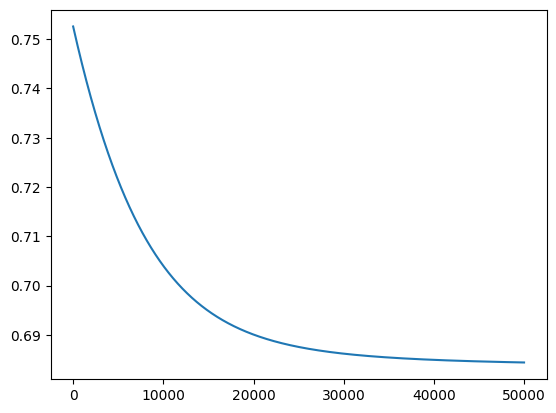

In [1165]:
# Import required preprocessing tool
from sklearn.preprocessing import OneHotEncoder

# Set random seed for reproducibility
np.random.seed(SEED)

# Prepare data for training
# Transpose inputs to shape (input_dim, batch_size)
inputs = flower_X.T

# One-hot encode targets to shape (num_classes, batch_size)
targets = OneHotEncoder().fit_transform(flower_y).toarray().T

# Initialize linear MLP with layer sizes [input, hidden, output]
linear_mlp = LinearMLP([2, 8, NUM_CLASSES])

##########################################
## TODO: find correct hyper-parameters
LINEAR_MLP_LR = 0.001
LINEAR_MLP_NSTEPS = 50000
##########################################

# Train the model and collect loss at each iteration
losses = train_linear_mlp(linear_mlp, LINEAR_MLP_LR,
                          LINEAR_MLP_NSTEPS, inputs, targets)

# Display final training loss
print(f"Final loss {losses[-1]}")

# Plot loss curve over training iterations
plt.plot(losses)

## Visualize Predictions and Targets

First, we define a helper function below to visualize the model predictions against target labels.

In [1166]:
# ============================================
# DO NOT MODIFY THIS CELL.
# ============================================

def plot_predictions(
    inputs: np.ndarray,
    targets: np.ndarray,
    model,
    title: str = "LinearMLP Predictions"
):
    '''
    Utility function to visualize model predictions against true labels.

    This function plots the dataset in 2D and colors points by predicted
    class, using the same Okabe–Ito color-blind friendly palette as the
    dataset visualization. Correctly classified points are shown as circles,
    and misclassified points are highlighted with "x" markers.

    Parameters
    ----------
    inputs : np.ndarray of shape (input_dim, batch_size)
        Input data used for generating predictions.
    targets : np.ndarray of shape (batch_size, 1)
        True class labels for each input sample.
    model : callable
        Model that outputs class logits when called on inputs.
    title : str, optional
        Title for the plot (default: "LinearMLP Predictions").
    '''
    # Compute model predictions
    y_pred = np.argmax(model(inputs), axis=0, keepdims=True)
    correct_mask = (y_pred == targets).flatten()

    # Determine number of unique predicted classes
    unique_classes = np.unique(y_pred)

    # Use Okabe–Ito color-blind friendly palette
    okabe_ito = [
        "#0072B2",  # blue
        "#D55E00",  # vermillion
        "#009E73",  # green
        "#F0E442",  # yellow
        "#CC79A7",  # pink
        "#56B4E9",  # sky blue
        "#E69F00",  # orange
        "#000000",  # black
    ]
    cmap = ListedColormap(okabe_ito[: max(1, unique_classes.size)])

    fig, ax = plt.subplots()

    # Plot correctly classified points (circles)
    ax.scatter(
        inputs.T[correct_mask, 0],
        inputs.T[correct_mask, 1],
        c=y_pred.T[correct_mask],
        cmap=cmap,
        label="Correct",
        s=20,
        marker="o",
    )

    # Plot misclassified points (crosses)
    ax.scatter(
        inputs.T[~correct_mask, 0],
        inputs.T[~correct_mask, 1],
        c=y_pred.T[~correct_mask],
        cmap=cmap,
        label="Wrong",
        s=60,
        marker="X",
        linewidths=1.2,
        edgecolors="#333333",
    )

    # Add a simple legend matching the style in visualize_classification_data
    handles = [
        plt.Line2D(
            [], [],
            marker="o", linestyle="",
            markerfacecolor=cmap(cls), markeredgecolor="none", markersize=6,
            label=f"Class {cls}"
        )
        for cls in unique_classes
    ]
    ax.legend(handles=handles + [plt.Line2D([], [], color="none",
                                            marker="x",
                                            markerfacecolor="none",
                                            markeredgecolor="black",
                                            label="Wrong prediction")],
              title="Legend", frameon=True)

    # Configure axes and legend
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_aspect("equal")
    ax.grid(False)
    plt.show()

Run the code below to generate the visualizations. Briefly discuss your observations.

Your observations: TODO

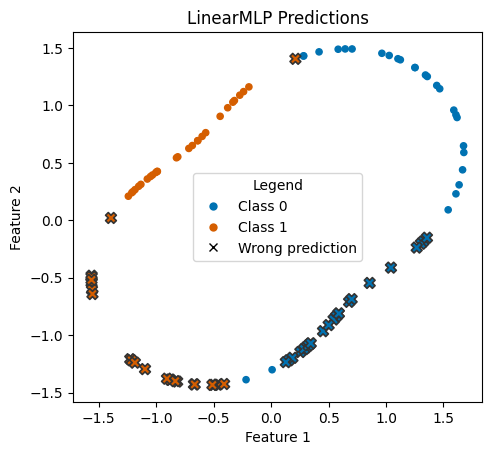

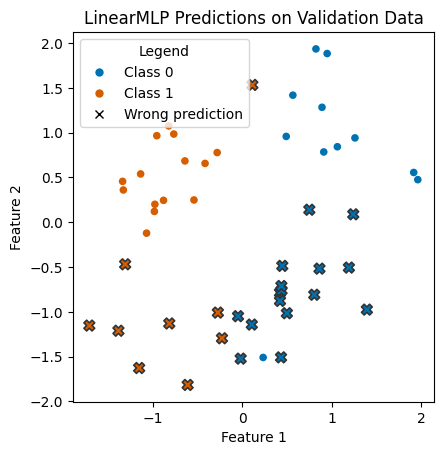

In [1167]:
# ============================================
# DO NOT MODIFY THIS CELL.
# ============================================

plot_predictions(flower_X.T, flower_y.T, linear_mlp, "LinearMLP Predictions")
plot_predictions(valid_X.T, valid_y.T, linear_mlp, "LinearMLP Predictions on Validation Data")

# Non-Linearities

The dataset in this homework is not a linearly separable problem unlike Homework 1. In the second part, you will extend your MLP by adding non-linear activation functions.

First, you will implement several elementwise nonlinearities.

## ReLU

Complete the two functions below to implement the ReLU nonlinearity and its derivative.

In [1168]:
def relu(x: np.typing.ArrayLike) -> np.typing.ArrayLike:
    '''
    Compute ReLU activation
    '''
    res = x
    ##########################################
    res = np.maximum(0, x)
    ##########################################
    assert res.shape == x.shape
    return res

In [1169]:
def relu_derivative(x: np.typing.ArrayLike) -> np.typing.ArrayLike:
    '''
    Compute the derivative of ReLU with respect to its input
    Assume derivative at 0 to be 0.
    '''
    res = x
    ##########################################
    res = np.where(x > 0, 1, 0)
    ##########################################
    assert res.shape == x.shape
    return res

## Sigmoid

Complete the two functions below to implement the Sigmoid nonlinearity and its derivative.

In [1170]:
def sigmoid(x: np.typing.ArrayLike) -> np.typing.ArrayLike:
    '''
    Compute sigmoid activation
    '''
    res = x
    ##########################################
    res = 1 / (1 + np.exp(-x))
    ##########################################
    assert res.shape == x.shape
    return res

In [1171]:
def sigmoid_derivative(x: np.typing.ArrayLike) -> np.typing.ArrayLike:
    '''
    Compute the derivative of sigmoid with respect to its inputs
    '''
    res = x
    ##########################################
    res = sigmoid(x) * (1 - sigmoid(x))
    ##########################################
    assert res.shape == x.shape
    return res

## ELU activation

Complete the two functions below to implement the Sigmoid nonlinearity and its derivative.

In [1172]:
def elu(x: np.typing.ArrayLike, alpha: float = 1.0) -> np.typing.ArrayLike:
    '''
    Compute ELU activation,

    ELU(x) = x if x > 0 else alpha * (exp(x) - 1)

    see https://docs.pytorch.org/docs/stable/generated/torch.nn.ELU.html
    '''
    res = x
    ##########################################
    
    res = np.where(x > 0, x, alpha * (np.exp(x) - 1))

    ##########################################
    assert res.shape == x.shape
    return res

In [1173]:
def elu_derivative(x: np.typing.ArrayLike, alpha: float = 1.0
) -> np.typing.ArrayLike:
    '''
    Compute the derivative of elu with respect to its inputs
    '''
    res = x
    ##########################################
    res = np.where(x > 0, 1, alpha * (np.exp(x)))
    ##########################################
    assert res.shape == x.shape
    return res

## Your Non-linearity

Implement any nonlinear elementwise activation function. You can look up other activations used in deep learning (tanh, GELU, SELU) or any suitable function.

In [1174]:
def your_nonlinear_func(x: np.typing.ArrayLike, alpha: float = 1.0) -> np.typing.ArrayLike:
    res = x
    ##########################################
    res = res = np.maximum((alpha * x), x)
    ##########################################
    assert res.shape == x.shape
    return res

## SqueLU

Someone decides that ReLU grows too quickly and comes up with a “clever” idea: take the square root of ReLU so the output grows more slowly. They define a new activation function:

$$\text{SqueLU}(x) = \sqrt{\text{ReLU}(x)}.$$

They argue that applying ReLU before the square root ensures the output is always real. But when they try training a model with this activation, the training quickly produces NaNs.

Your tasks:

*   Implement SqueLU and its derivative in the cell below.
*   Explain why `NaN`s appear almost immediately during training.

In [1175]:
def squelu(x: np.typing.ArrayLike) -> np.typing.ArrayLike:
    '''
    Compute the SqueLU function
    SqueLU = \sqrt{ReLU(x)}
    '''
    res = x
    ##########################################
    res = np.sqrt(relu(x))
    ##########################################
    assert res.shape == x.shape
    return res

In [1176]:
def squelu_derivative(x: np.typing.ArrayLike) -> np.typing.ArrayLike:
    '''
    Compute the derivative of the SqueLU function
    '''
    res = x
    ##########################################
    res = (1/(2 * np.sqrt(relu(x))))* relu_derivative(x)
    ##########################################
    assert res.shape == x.shape
    return res

## Visualize Non-Linearities
Let's visualize these non-linearities. Before running the cell, it is a good practice to sketch how each function and their derivative would look like.

/tmp/ipykernel_1290/3315764343.py:7: RuntimeWarning: divide by zero encountered in divide
  res = (1/(2 * np.sqrt(relu(x))))* relu_derivative(x)
/tmp/ipykernel_1290/3315764343.py:7: RuntimeWarning: invalid value encountered in multiply
  res = (1/(2 * np.sqrt(relu(x))))* relu_derivative(x)


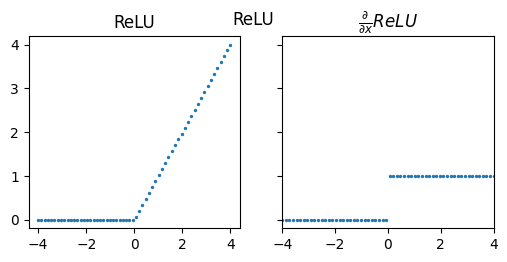

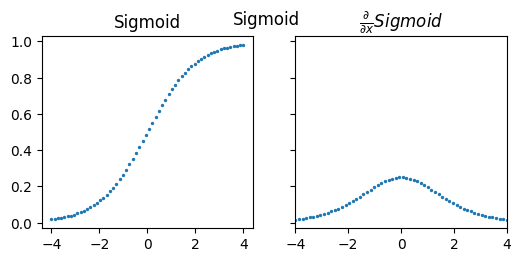

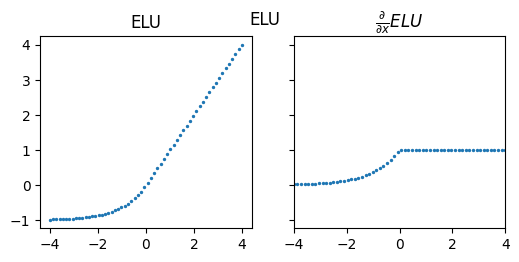

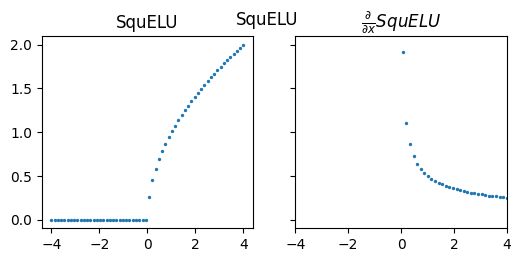

In [1177]:
# ============================================
# DO NOT MODIFY THIS CELL.
# ============================================


# Define x-axis range for plotting activation functions
xaxis = np.linspace(-4, 4, 60)

# List of activation functions and their derivatives to visualize
functions = [relu, sigmoid, elu, squelu]
derivative_functions = [relu_derivative, sigmoid_derivative,
                        elu_derivative, squelu_derivative]
func_names = ["ReLU", "Sigmoid", "ELU", "SquELU"]

# Plot each activation function alongside its derivative
for func, der, name in zip(functions, derivative_functions, func_names):
    # Create side-by-side subplots for function and derivative
    fig, axs = plt.subplots(1, 2, sharey=True, figsize=(6, 2.5))
    axs = axs.flat

    # Left plot: activation function
    axs[0].scatter(xaxis, func(xaxis), s=2)
    axs[0].set_title(name)

    # Right plot: derivative of activation function
    axs[1].set_title(rf"$\frac{{\partial }}{{\partial x}} {name}$")
    axs[1].scatter(xaxis, der(xaxis), s=2)
    axs[1].set_xlim(xaxis[0], xaxis[-1])

    # Overall figure title
    fig.suptitle(name)

# ReLU MLP

In this section, you will implement several functions to build a multi-layer perceptron with ReLU activation functions in the hidden layers. By adding this non-linearity, your network will be able to learn complex decision boundaries that a linear model cannot capture.

## The ReLU MLP Class

In [1178]:
class ReLUMLP:
    def __init__(self, layer_widths: List[int]):
        # Create the layers of MLP
        # This is the same as LinearMLP initialization
        self.layers = []
        ##########################################
        for i in range(len(layer_widths) - 1):
            d_in = layer_widths[i]
            d_out = layer_widths[i + 1]

            layer = Layer(d_in, d_out)

            self.layers.append(layer)
        ##########################################

    def __call__(self, X: np.typing.ArrayLike) -> np.typing.ArrayLike:
        # Implement forward pass of the ReLU MLP
        # Don't forget to apply ReLU after each layer except the last
        res = X
        ##########################################
        
        for i, layer in enumerate(self.layers):
            if i != (len(self.layers) - 1):            
                res = relu(layer(res))
            else: 
                res = layer(res)
        
        ##########################################
        return res

## The Forward Pass

In [1179]:
def compute_relu_mlp_forward_passes(
    network: LinearMLP, inputs: np.typing.ArrayLike
) -> Tuple[List[np.typing.ArrayLike], List[np.typing.ArrayLike]]:
    '''
    Compute forward pass through a ReLU MLP network.

    This function performs a forward pass through all layers, applying ReLU
    activation to hidden layers while keeping the output layer linear. It
    stores both pre-activations and post-activations for use in backpropagation.

    Parameters
    ----------
    network : LinearMLP
        The multi-layer perceptron network.
    inputs : np.ndarray
        Input features of shape (input_dim, batch_size).

    Returns
    -------
    layer_outputs : List[np.ndarray]
        Post-activation outputs for each layer (index 0 is the input).
    pre_activations : List[np.ndarray]
        Pre-activation values for each layer (index 0 is the input).
    '''

    layer_outputs = [inputs]
    pre_activations = [inputs]
    ##########################################
    x = inputs

    for i, layer in enumerate(network.layers):
        z = layer(x)
        pre_activations.append(z) 
        
        if i != len(network.layers) - 1:
            x = relu(z)
        else:
            x = z

        layer_outputs.append(x)
        
    ##########################################
    assert len(layer_outputs) == len(network.layers) + 1, (
        "Layer outputs should match number of layers"
    )
    assert len(pre_activations) == len(network.layers) + 1, (
        "Pre-activations should match number of layers"
    )
    return layer_outputs, pre_activations

## Cost Derivatives

In [1180]:
def compute_relu_mlp_partial_derivatives(
    network: LinearMLP,
    cost_partials: List[np.typing.ArrayLike],
    pre_activations
):

    for ind, (layer, pre_activation) in enumerate(
        zip(reversed(network.layers), reversed(pre_activations))
    ):
        # Compute the error signal propagated to each layer
        ## Hint: After reversal, cost_partials[i]: d L / d z_i
        ## Hint: Cost partials: d L / d z_l =
        ## d L / d z_{l+1} * d z_{l+1} / d h_{l+1} * d h_l / d z_l
        ## where h_l is the pre-activation
        ##########################################
        grad_loss_wrt_z_L = cost_partials[ind]
        weights_wrt_L = layer.weights
        relu_deriv = relu_derivative(pre_activations[ind + 1])
        # relu_deriv = relu_derivative(pre_activation)

        gradient = np.matmul(weights_wrt_L.T, grad_loss_wrt_z_L) * relu_deriv
        cost_partials.append(gradient)
        
        ##########################################

    cost_partials.reverse()
    assert len(cost_partials) == len(network.layers) + 1, (
        "Cost partials should have one more element than layers"
    )

## Weight and Bias Gradients

In [1181]:
def compute_relu_mlp_parameter_updates(
    cost_partials: List[np.typing.ArrayLike],
    pre_activations: List[np.typing.ArrayLike],
) -> Tuple[List[np.typing.ArrayLike], List[np.typing.ArrayLike]]:

    weight_gradients = []
    bias_gradients = []
    batch_size = pre_activations[0].shape[1]

    # Compute weight gradient
    ##########################################
    num_layers = len(pre_activations) - 1

    for i in range(num_layers):
       grad_loss_wrt_z_L = cost_partials[i + 1]
       pre_activation = pre_activations[i]
       grad_loss_wrt_w_L = np.matmul(grad_loss_wrt_z_L, relu(pre_activation).T) / batch_size
       weight_gradients.append(grad_loss_wrt_w_L)
    ##########################################
    assert len(weight_gradients) == len(pre_activations) - 1, (
        "Weight gradients should match number of layers"
    )

    # Compute bias gradient
    ##########################################
    for i in range(num_layers):
        grad_loss_wrt_z_L = cost_partials[i + 1]
        bias_grad = np.sum(grad_loss_wrt_z_L, axis=1, keepdims=True) / batch_size
        bias_gradients.append(bias_grad)
    ##########################################
    assert len(bias_gradients) == len(pre_activations) - 1, (
        "Bias gradients should match number of layers"
    )
    return weight_gradients, bias_gradients

## One Training Step for ReLU MLP

The `step_relu_network` function below runs one complete training step for a ReLU MLP network. It handles the forward pass, calculates the loss, backpropagates the gradients, updates the parameters, and returns the loss so you can track how training is going.

In [1182]:
# ============================================
# DO NOT MODIFY THIS CELL.
# ============================================

def step_relu_network(network, inputs, targets, learning_rate) -> float:
    '''
    Perform one training step for a ReLU MLP network.

    Executes forward pass, computes loss, backpropagates gradients,
    and updates network parameters.

    Parameters
    ----------
    network : ReluMLP
        The neural network to train.
    inputs : np.ndarray
        Input features of shape (input_dim, batch_size).
    targets : np.ndarray
        One-hot encoded target labels of shape (num_classes, batch_size).
    learning_rate : float
        Step size for gradient descent.

    Returns
    -------
    float
        Cross-entropy loss for this batch.
    '''

    # Forward pass: compute activations and pre-activations for all layers
    layer_outputs, pre_activations = compute_relu_mlp_forward_passes(
        network, inputs)

    # Apply softmax to final layer output to get class probabilities
    probs = softmax(layer_outputs[-1])

    # Compute cross-entropy loss: -1/N * sum y log p
    n = targets.shape[1]  # Number of examples in the batch
    loss = cross_entropy_loss(probs, targets)

    # Backpropagation: compute gradients with respect to all parameters
    weight_gradients = []
    bias_gradients = []

    # Initialize cost partials with gradient of loss w.r.t. final layer output
    cost_partials = [1.0 / n * (probs - targets)]

    # Backpropagate through all layers to compute cost partials
    compute_relu_mlp_partial_derivatives(
        network, cost_partials, pre_activations)

    # Compute weight and bias gradients using cost partials and activations
    weight_gradients, bias_gradients = compute_relu_mlp_parameter_updates(
        cost_partials, pre_activations)

    # Update network parameters using computed gradients
    update_parameters(network, weight_gradients,
                      bias_gradients, learning_rate)

    return loss

## Training Loop for ReLU MLP

The `train_relu_mlp` function trains a ReLU MLP network by repeatedly calling `step_relu_network` for a specified number of iterations. It collects and returns the loss at each step so you can monitor how well the network is learning over time.

In [1183]:
# ============================================
# DO NOT MODIFY THIS CELL.
# ============================================

def train_relu_mlp(mlp,
                   learning_rate: float,
                   n_iterations: int,
                   inputs: np.typing.ArrayLike,
                   targets: np.typing.ArrayLike
) -> List[float]:
    '''
    Train a ReLU MLP using gradient descent.

    Parameters
    ----------
    mlp : ReLUMLP
        The neural network to train.
    learning_rate : float
        Step size for gradient descent.
    n_iterations : int
        Number of training iterations.
    inputs : np.ndarray
        Input features of shape (input_dim, batch_size).
    targets : np.ndarray
        One-hot encoded target labels of shape (num_classes, batch_size).

    Returns
    -------
    List[float]
        Loss value at each iteration.
    '''
    losses = []
    for _ in range(n_iterations):
        loss = step_relu_network(mlp, inputs, targets, learning_rate)
        losses.append(loss)
    return losses

## Train ReLU-MLP

Run the code below to train the ReLU-MLP you implemented. Adjust the hyperparameters `RELU_MLP_LR` and `RELU_MLP_NSTEPS` until you achieve < 0.1 loss.

Report your final hyperparameters and loss below:

* final `RELU_MLP_LR` = TODO
* final `RELU_MLP_NSTEPS` = TODO
* final loss (with 2 decimal places) = TODO

Final loss 0.009866709207301422


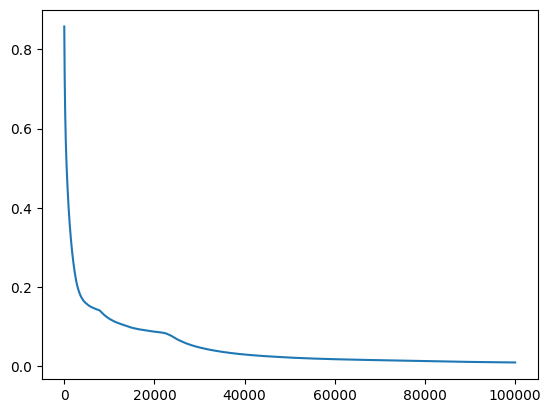

In [1189]:
# Prepare data for training
np.random.seed(SEED)

# Transpose inputs to shape (input_dim, batch_size)
inputs = flower_X.T

# One-hot encode targets to shape (num_classes, batch_size)
targets = OneHotEncoder().fit_transform(flower_y).toarray().T

# Initialize ReLU MLP with layer sizes [input, hidden1, hidden2, output]
relu_mlp = ReLUMLP([2, 16, 16, NUM_CLASSES])

##########################################
## TODO: find correct hyper-parameters
RELU_MLP_LR = 0.1
RELU_MLP_NSTEPS = 100000
##########################################

# Train the model
losses = train_relu_mlp(relu_mlp, RELU_MLP_LR, RELU_MLP_NSTEPS,
                        inputs, targets)

# Display training results
print(f"Final loss {losses[-1]}")
plt.plot(losses)

## Visualize Predictions and Targets

Run the code below to visualize the model predictions against the true target labels. Briefly discuss your observations.

Your observations: TODO

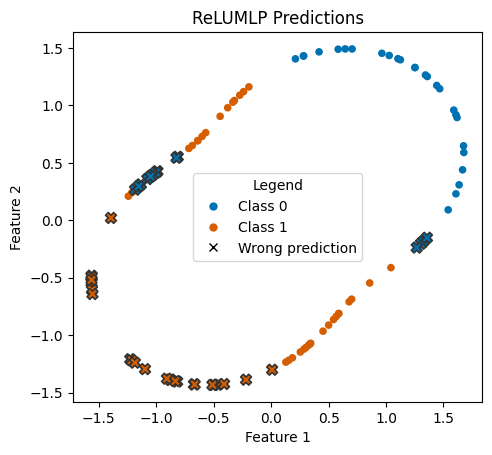

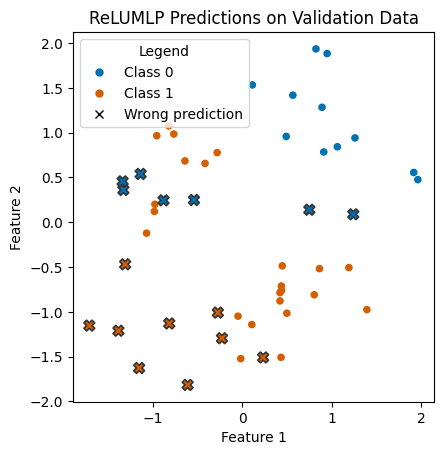

In [1185]:
# Visualize predictions on training and validation sets
plot_predictions(flower_X.T, flower_y.T, relu_mlp,
                 "ReLUMLP Predictions")

plot_predictions(valid_X.T, valid_y.T, relu_mlp,
                 "ReLUMLP Predictions on Validation Data")